# Architecture scaling ablation
We study the effect of scaling the number of training architectures on the downstream validation performance by measuring the **heldout data accuracy** of **heldout architectures** after training for a fixed number of steps. **All architectures have the same depth**.

## Dataset: ```FashionMNIST```

**Architectures**
- MLPs
- fixed depth (3 layers), nonincreasing layer dimensions $\in \{16, 32, 64, 128\}$.

**Training**
- 1.2K metaepochs
- Data batch size 512
- Number of train architectures $\in \{1, 2, 4, 8\}$
- LR 0.001
- Incremental update step curriculum; increment number of update rounds every 100 metaepochs until $n_{\mathrm{updates}}=10$.

In [26]:
fig_extension = "pdf"

In [27]:
import numpy as np
import json
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from pathlib import Path
import re
from functools import reduce
from operator import mul

In [28]:
def read_jsonl(filename: str) -> pd.DataFrame:
    with open(filename, "r") as f:
        return pd.DataFrame.from_records(list(map(json.loads, f.read().splitlines())))

In [29]:
# adam baseline: every architecture is trained to convergence with Adam.
with open("../data/adam_baselines_fashion_mnist.json", "r") as f:
    adam_df = pd.DataFrame.from_dict(json.loads(f.read()), orient="index").reset_index()
adam_depth3 = adam_df[adam_df.depth == 3]

In [30]:
adam_val_acc_mean = adam_depth3["val_acc"].mean()
adam_val_acc_std = adam_depth3["val_acc"].std()

In [31]:
result_df = pd.concat((read_jsonl(fn) for fn in Path("../data/fixed3").rglob("*.jsonl")), ignore_index=True)

In [32]:
result_df = result_df.sort_values(by=["T", "rep"])

In [33]:
n_val_archs = result_df[result_df.split == "val"].arch_id.unique().size

In [34]:
stds = result_df.groupby("T")[["val_acc_mean"]].std().reset_index()
means = result_df.groupby("T")[["val_acc_mean"]].mean().reset_index()
stats = pd.merge(stds, means, on="T", suffixes=("_std", ""))

In [35]:
result_df.groupby("T")[["val_acc_mean"]].mean()

,val_acc_mean
T,
1,0.448816
2,0.731860
4,0.872594
8,0.871117


In [36]:
adam_val_acc_mean

np.float64(0.8849747402327401)

In [37]:
result_df[result_df.split == "train"].groupby("T")[["val_acc_mean"]].mean()

,val_acc_mean
T,
1,0.881554
2,0.876819
4,0.876966
8,0.877044


<Figure size 640x480 with 0 Axes>

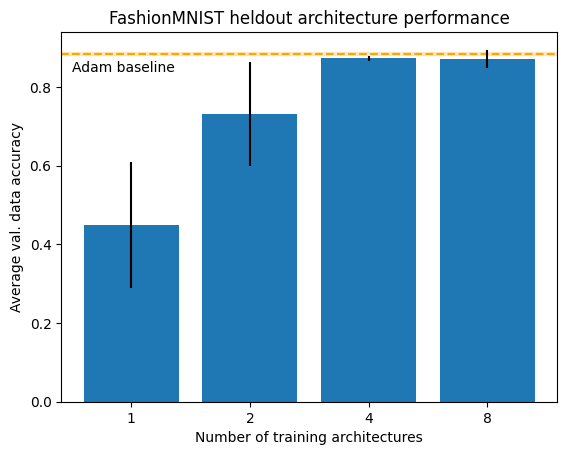

In [38]:
plt.clf()
stats = pd.merge(stds, means, on="T", suffixes=("_std", ""))
stats["ci95"] = 1.96 * (stats.val_acc_mean_std / np.sqrt(n_val_archs))
ci95_adam = 1.96 * (adam_val_acc_std / np.sqrt(n_val_archs))
fig, ax = plt.subplots(1)
xpos = np.arange(0, len(stats))
ax.bar(xpos, "val_acc_mean", yerr="ci95", data=stats)
ax.set_xticks(ticks=xpos, labels=stats["T"])
ax.set_xlabel("Number of training architectures")
ax.set_title("FashionMNIST heldout architecture performance")
ax.set_ylabel("Average val. data accuracy")
ax.axhline(adam_val_acc_mean, linestyle="--", color="orange", label="Adam", zorder=-1)
ax.axhspan(adam_val_acc_mean + ci95_adam, adam_val_acc_mean - ci95_adam , color="orange", alpha=0.2)

plt.text(-0.5, 0.84, "Adam baseline")
plt.savefig(f"../figures/fashion_mnist_fixed_depth.{fig_extension}", bbox_inches="tight")
plt.show()

Errorbars represent the 95% confidence interval of the mean validation accuracy over the possible architecture configurations.

In [39]:
def arch(s: str) -> tuple[int, ...]:
    spl = re.split("[-_]", s)
    if not spl:
        raise ValueError(f"{spl} / {s}")
    if spl[0].startswith("d"):
        spl = spl[1:]
    return tuple(int(x) for x in spl)
    

In [40]:
result_df["arch_tuple"] = result_df.arch_id.apply(arch)

# Distance to training set
Each architecture is an architecture of depth $\ell = 4$ with 
- Weight matrices $\{ W_i \}_{i=1}^{\ell}$, where $W_i \in \mathbb{R}^{d_{i-1} \times d_{i}}$.
- $d_0 = 784, d_4 = 10$.

Each architecture can therefore be described by the vector of its weight dimensionalities, omitting $d_0$ and $d_4$:
$$
A = \begin{bmatrix}
d_1 & d_2 & d_3
\end{bmatrix}
$$
We omit the conserved positions $d_0, d_4$ and define the distance between two architectures as the cosine distance of the $d_1, d_2, d_3$ coordinates of their architecture vectors:

$$
\begin{align}
d(A, B) &= 1 - \frac{A \cdot B}{\lVert A \rVert \lVert B \rVert}.
\end{align}
$$

In [41]:
trials = []
for (T, rep), trial_df in result_df.groupby(["T", "rep"]):
    is_train = trial_df.split == "train"
    trial_train = trial_df[is_train]
    trial_val = trial_df[~is_train]

    
    train_architectures = trial_train.arch_tuple.values.tolist()
    val_architectures = trial_df.arch_tuple.values.tolist()

    train_mat = np.vstack([np.asarray(arch) for arch in train_architectures])
    val_mat = np.vstack([np.asarray(arch) for arch in val_architectures])

    #distances = np.linalg.norm(
    #    val_mat[:, None, :] - train_mat[None, :, :],
    #    axis=-1,
    #    ord=2
    #)
    num = val_mat @ train_mat.T
    denom = np.linalg.norm(val_mat, axis=-1, ord=2)[:, None] * np.linalg.norm(train_mat, axis=-1, ord=2)[None, :]
    distances =  1 - (num / denom)
    
    min_distances = distances.min(axis=-1)
    trial_df["min_distance_to_train"] = min_distances
    trials.append(trial_df)

result_df_distance = pd.concat(trials)

In [42]:
result_df_distance["num_parameters"] = result_df_distance.arch_tuple.apply(lambda x: reduce(mul, x))
val_dist = result_df_distance[result_df_distance.split == "val"]

In [43]:
val_dist[["min_distance_to_train", "val_acc_mean"]].corr()

,min_distance_to_train,val_acc_mean
min_distance_to_train,1.00000,-0.72749
val_acc_mean,-0.72749,1.00000


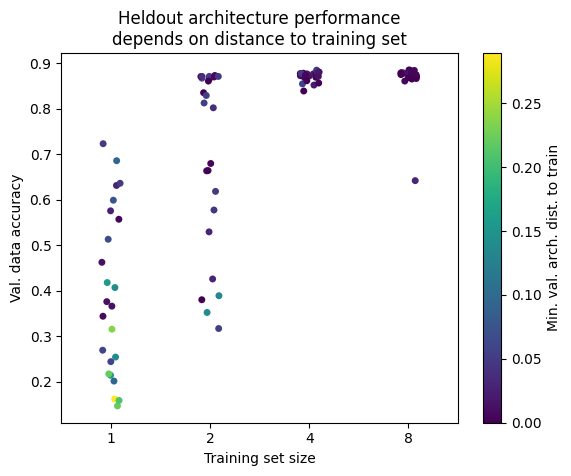

In [44]:
fig, ax = plt.subplots()

val_dist = result_df_distance[result_df_distance.split == "val"]

sns.stripplot(
    data=val_dist, x="T", y="val_acc_mean",
    hue="min_distance_to_train",
    palette="viridis",
    legend=False,       # suppress the legend
    ax=ax,
)

# build a colorbar that matches the hue mapping
norm = mpl.colors.Normalize(val_dist.min_distance_to_train.min(),
                            val_dist.min_distance_to_train.max())
sm = mpl.cm.ScalarMappable(norm=norm, cmap="viridis")
fig.colorbar(sm, ax=ax, label="Min. val. arch. dist. to train")
ax.set_xlabel("Training set size")
ax.set_ylabel("Val. data accuracy")
ax.set_title("Heldout architecture performance\ndepends on distance to training set")
plt.savefig(f"../figures/fashion_mnist_heldout_arch_perf.{fig_extension}", bbox_inches="tight")
plt.show()

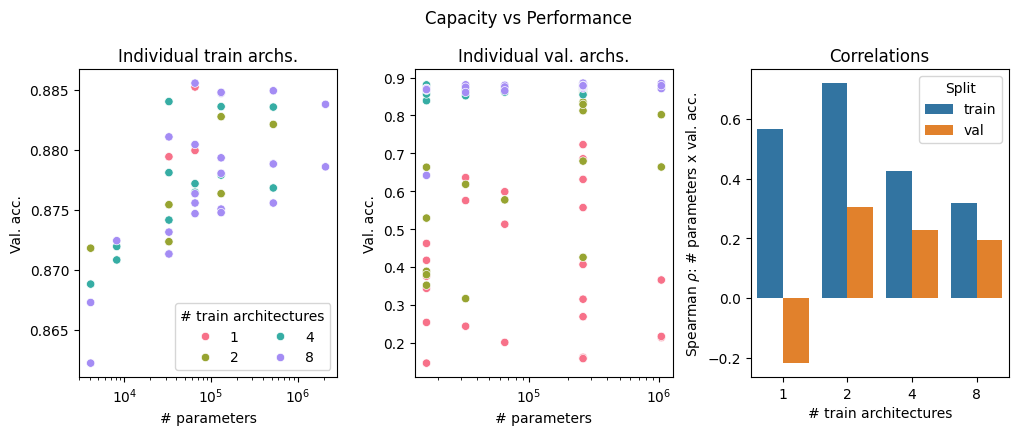

In [45]:
train_dist = result_df_distance[result_df_distance.split == "train"]
result_df_distance["T_split"] = "(" + result_df_distance["T"].astype(str) + ", " + result_df_distance["split"].astype(str) + ")"
fig, (ax2, ax3, ax1) = plt.subplots(1, 3, figsize=(12, 4))
sns.scatterplot(
    result_df_distance[result_df_distance.split == "train"],
    x="num_parameters",
    y="val_acc_mean",
    hue="T",
    palette=sns.color_palette("husl", 4),
    ax=ax2,
    legend=True,
)

sns.scatterplot(
    result_df_distance[result_df_distance.split == "val"],
    x="num_parameters",
    y="val_acc_mean",
    hue="T",
    palette=sns.color_palette("husl", 4),
    ax=ax3,
    legend=False,
)


leg = ax2.legend(ncols=2)

leg.set_title("# train architectures")
ax2.set_xscale("log")
ax2.set_ylabel("Val. acc.")
ax2.set_xlabel("# parameters")
ax2.set_title("Individual train archs.")
ax3.set_title("Individual val. archs.")
ax3.set_xlabel("# parameters")
ax3.set_xscale("log")
ax3.set_ylabel("Val. acc.")


param_acc_corrs = result_df_distance.groupby(["split", "T"])[["num_parameters", "val_acc_mean"]].corr().reset_index()
param_acc_corrs = param_acc_corrs[param_acc_corrs.level_2 == "num_parameters"][["split", "T", "val_acc_mean"]]
sns.barplot(param_acc_corrs, x="T", y="val_acc_mean", hue="split", ax=ax1)
ax1.set_ylabel(r"Spearman $\rho$: # parameters x val. acc.")
ax1.set_xlabel(r"# train architectures")
ax1.set_title("Correlations")
leg = ax1.legend()
leg.set_title("Split")
plt.subplots_adjust(wspace=0.3)
fig.suptitle("Capacity vs Performance", y=1.03)
plt.savefig(f"../figures/fashion_mnist_capacity_x_perf.{fig_extension}")
plt.show()